In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [12]:
df=pd.read_csv("diabetes.csv")

In [13]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
df.shape

(768, 9)

In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [18]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [20]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


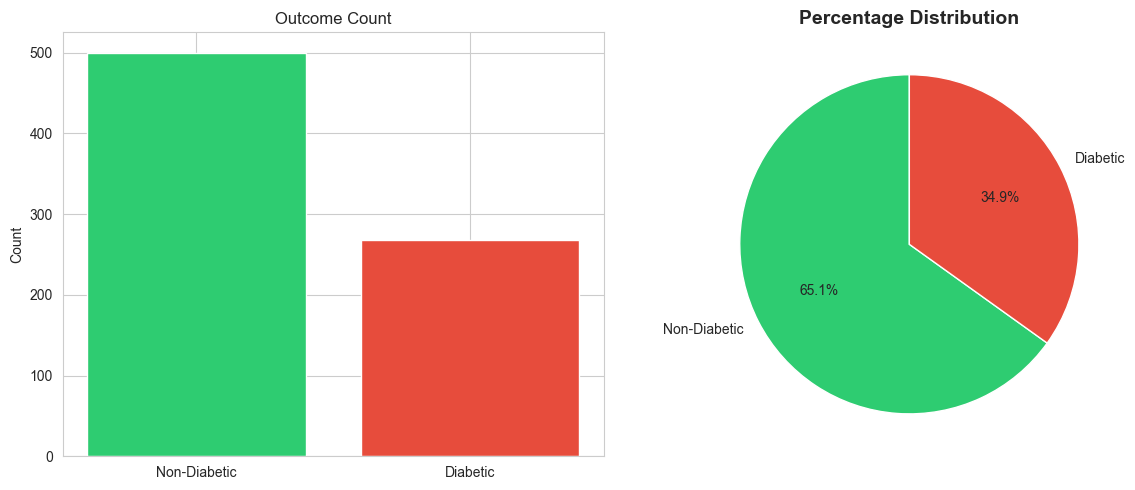

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Bar Chart (Left)
plt.subplot(1,2,1)
outcome_counts = df['Outcome'].value_counts()
plt.bar(['Non-Diabetic', 'Diabetic'],
        outcome_counts.values,
        color=['#2ecc71', '#e74c3c'])
plt.ylabel('Count')
plt.title('Outcome Count')

# Pie Chart (Right)
plt.subplot(1,2,2)
plt.pie(outcome_counts.values,
        labels=['Non-Diabetic', 'Diabetic'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90)
plt.title('Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()   # Thoda spacing dega
plt.show()

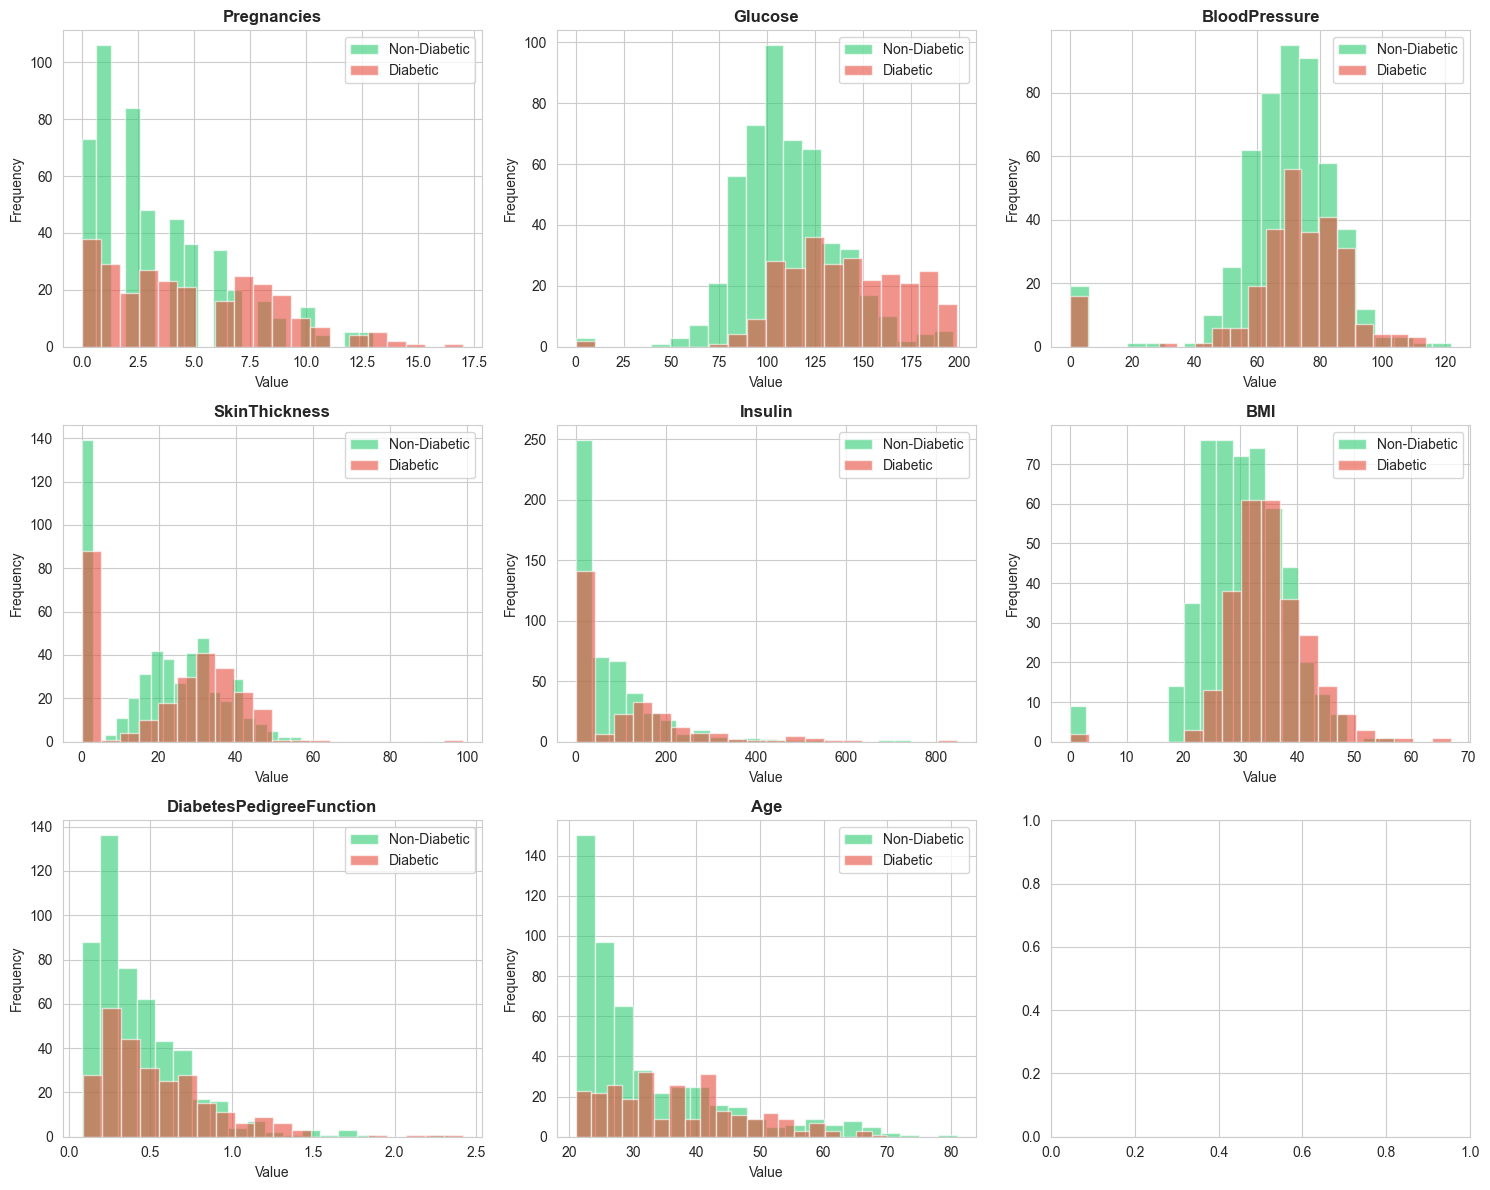

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

features = df.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3

    for outcome in [0, 1]:
        data = df[df['Outcome'] == outcome][feature]

        axes[row, col].hist(
            data,
            bins=20,
            alpha=0.6,
            label='Non-Diabetic' if outcome == 0 else 'Diabetic',
            color='#2ecc71' if outcome == 0 else '#e74c3c'
        )

    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

In [35]:
x = df.drop(columns='Outcome',axis=1)
y= df['Outcome']

print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)
x

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

print(x.shape,x_train.shape,y_train.shape)

(768, 8) (614, 8) (614,)


In [43]:
from sklearn import svm

classifier = svm.SVC(kernel='linear', probability=True)
classifier.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [46]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction,y_train)
training_data_accuracy

0.7866449511400652

In [48]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction,y_test)
test_data_accuracy

0.7727272727272727

In [49]:
precision = precision_score(y_test,x_test_prediction)
recall = recall_score(y_test,x_test_prediction)
f1 = f1_score(y_test,x_test_prediction)

print(precision,recall,f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [51]:
cm_svm = confusion_matrix(y_test,x_test_prediction)
cm_svm

array([[91,  9],
       [26, 28]])

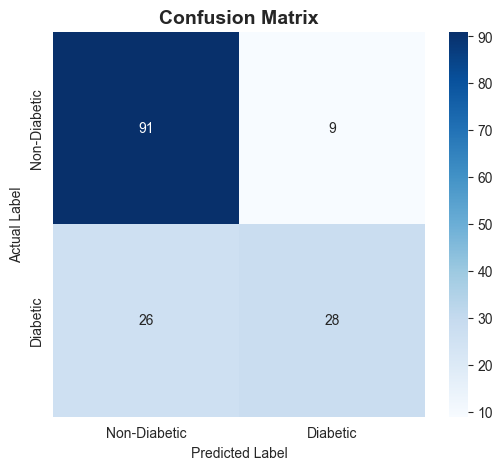

In [53]:
cm_svm= confusion_matrix(y_test, x_test_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.show()

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [56]:
classifier.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = classifier.predict(x_test)

In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7597402597402597


In [59]:
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 75.97%


In [60]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6976744186046512


In [61]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.5555555555555556


In [62]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-Score:", f1)

F1-Score: 0.6185567010309279


In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82       100
           1       0.70      0.56      0.62        54

    accuracy                           0.76       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.76      0.75       154



In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[87 13]
 [24 30]]


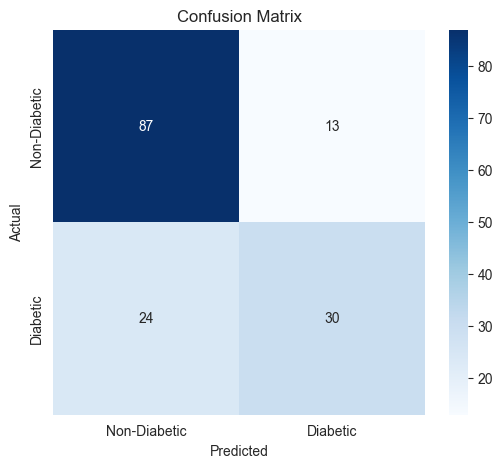

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82       100
           1       0.70      0.56      0.62        54

    accuracy                           0.76       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.76      0.75       154



In [67]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Importance': classifier.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                    Feature  Importance
1                   Glucose    0.268406
5                       BMI    0.166637
7                       Age    0.132485
6  DiabetesPedigreeFunction    0.124538
0               Pregnancies    0.088602
2             BloodPressure    0.087266
3             SkinThickness    0.066827
4                   Insulin    0.065239


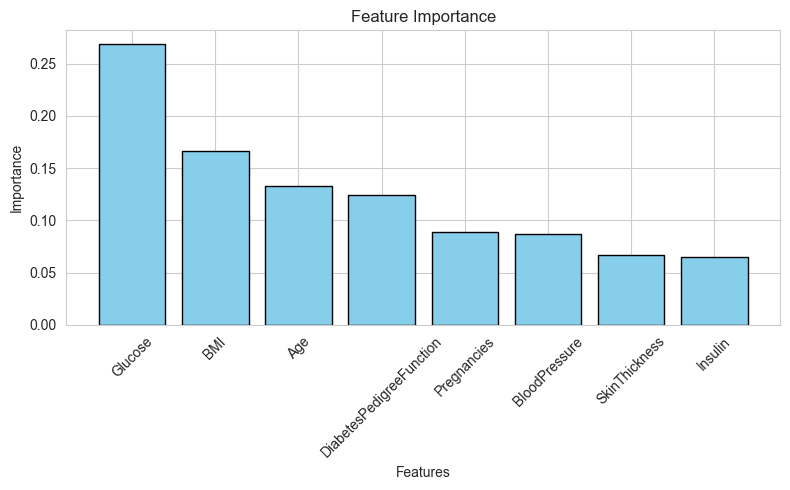

In [68]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance'],
    color='skyblue',
    edgecolor='black'
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

In [69]:
print('svm',test_data_accuracy)
print('Random Forest',test_data_accuracy)

svm 0.7727272727272727
Random Forest 0.7727272727272727


In [71]:
joblib.dump(classifier,'diabetes_model.pkl')

['diabetes_model.pkl']

In [72]:
input_data = (5,166,72,19,25,8,0.587,51)
input_num_array = np.asanyarray(input_data)
reshape = input_num_array.reshape(1,-1)

std_data = scaler.transform(reshape)
prediction= classifier.predict(std_data)


In [73]:
prediction

array([1])

In [74]:
import joblib

# Trained model save karo
joblib.dump(classifier, "diabetes_model.pkl")

# Scaler save karo
joblib.dump(scaler, "scaler_svm.pkl")

print("✅ Model and Scaler Saved Successfully!")

✅ Model and Scaler Saved Successfully!
